# Exploratory Data Analysis

Four things I want to check:
1. How did the four stocks actually perform over the period?
2. What do the return distributions look like?
3. How correlated are these stocks with each other?
4. Is there any visible relationship between the Google Trends data and stock returns?

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}

prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
trends = pd.read_csv('data/trends.csv', index_col=0, parse_dates=True)
macro  = pd.read_csv('data/macro.csv',  index_col=0, parse_dates=True)
prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

print('Prices:', prices.shape)
print('Trends', trends.shape)
print('Macro:', macro.shape)

Prices: (1550, 4)
Trends (72, 3)
Macro: (72, 2)


## 2. Stock Price Performance

Raw prices aren't directly comparable because the stocks trade in different currencies and at very different price levels. Normalizing everything to 100 at the start of the period puts them on the same scale so 120 means "up 20% from the start", regardless of the currency.

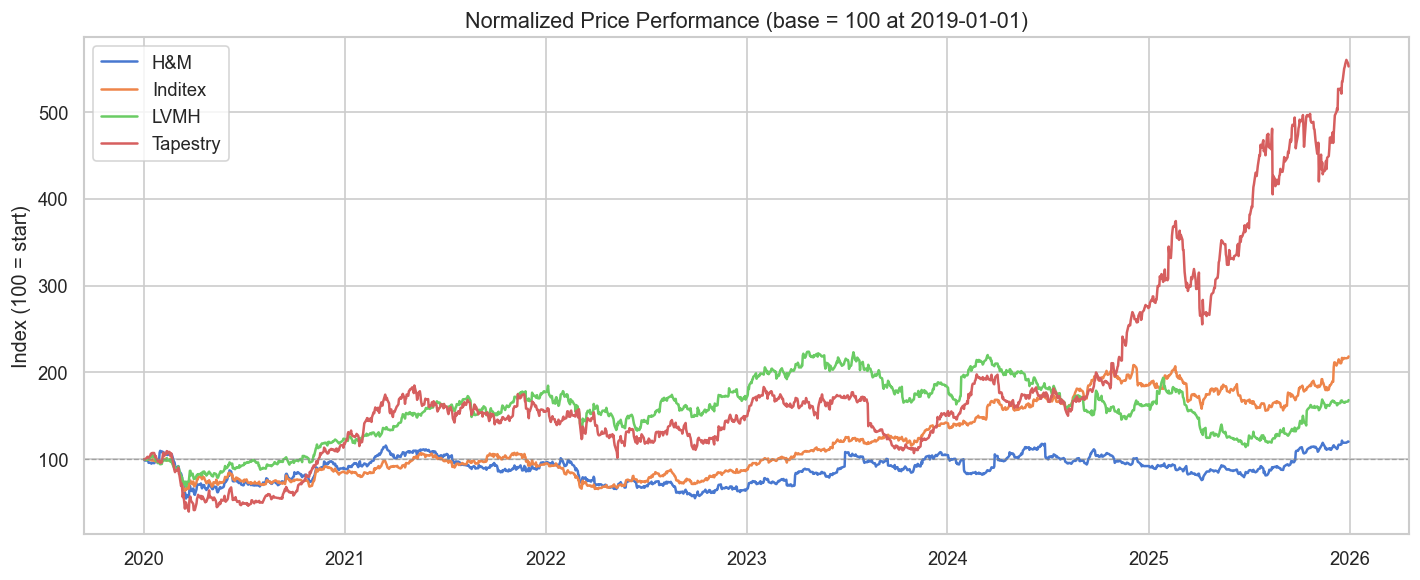

In [2]:
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))

for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_title('Normalized Price Performance (base = 100 at 2019-01-01)', fontsize=13)
ax.set_ylabel('Index (100 = start)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Daily Log Returns

Log returns are better than simple percentage returns for financial analysis. They're additive over time and more symmetric, which makes them better-behaved mathematically. The formula is just $r_t = \ln(P_t / P_{t-1})$.

I'm plotting the distribution of each stock's returns to see how fat the tails are and whether there are obvious outliers.

In [3]:
log_returns = np.log(prices / prices.shift(1)).dropna()

stats = log_returns.describe().T
stats['skew']     = log_returns.skew()
stats['kurtosis'] = log_returns.kurt()
stats['ann_vol']  = log_returns.std() * np.sqrt(252)
print(stats[['mean', 'std', 'min', 'max', 'skew', 'kurtosis', 'ann_vol']].round(4))

            mean     std     min     max    skew  kurtosis  ann_vol
H&M       0.0001  0.0228 -0.1389  0.1670  0.1829    8.9504   0.3620
Inditex   0.0005  0.0177 -0.1113  0.1313  0.2447    5.8002   0.2815
LVMH      0.0003  0.0190 -0.0908  0.1206  0.3492    4.4117   0.3014
Tapestry  0.0011  0.0311 -0.3463  0.2599 -0.8629   17.2196   0.4938


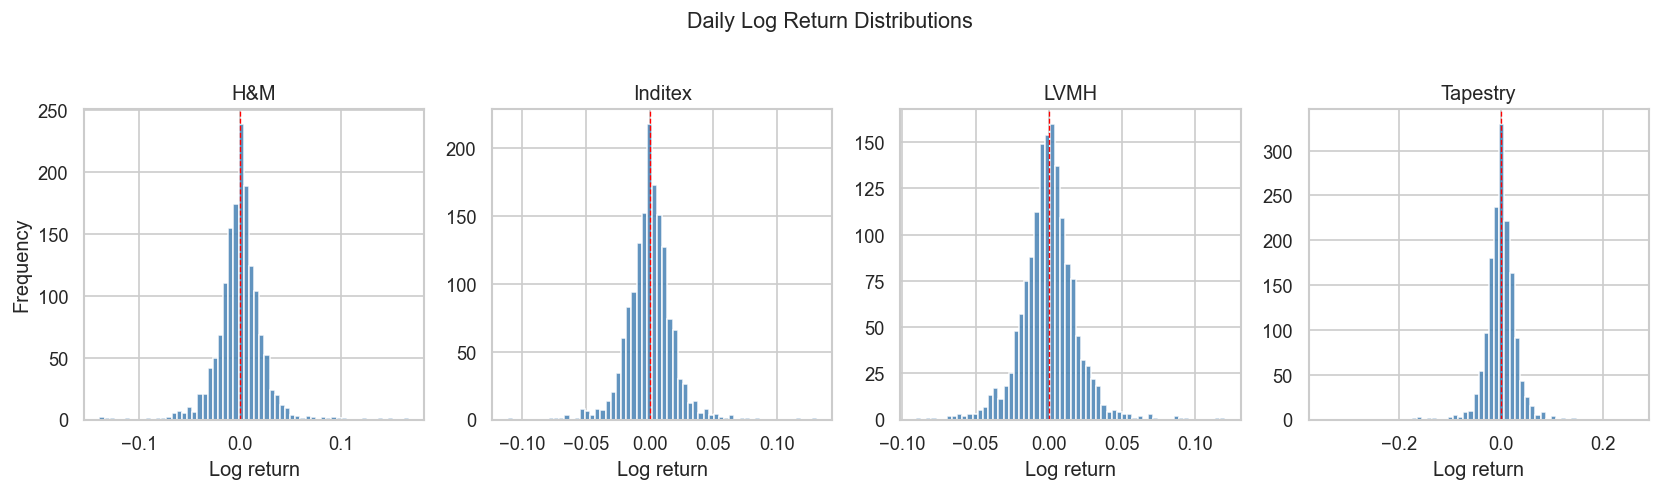

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

for ax, col in zip(axes, log_returns.columns):
    ax.hist(log_returns[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('Log return')

axes[0].set_ylabel('Frequency')
fig.suptitle('Daily Log Return Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlation Between Stocks

Portfolio diversification only works if the stocks don't move perfectly together. If everything goes up and down at the same time, holding four stocks isn't better than holding one. The correlation matrix shows how much each pair of stocks moves in sync.

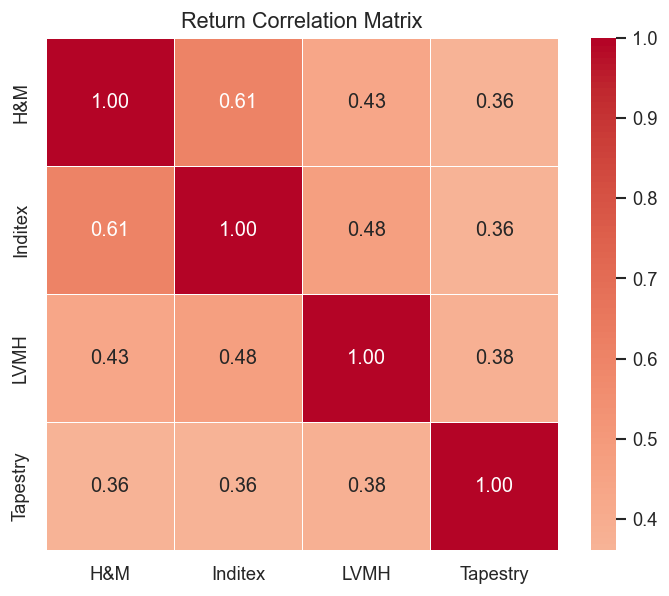

In [5]:
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Return Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Google Trends Timeline

This is the part I was most curious about. The three keywords track different ends of the fashion market -"quiet luxury" is aspirational and high-end, "streetwear" is mass-market, "zara haul" is basically a direct signal for Inditex. Plotting them together should show whether the trends move independently or whether they're driven by the same underlying consumer mood.

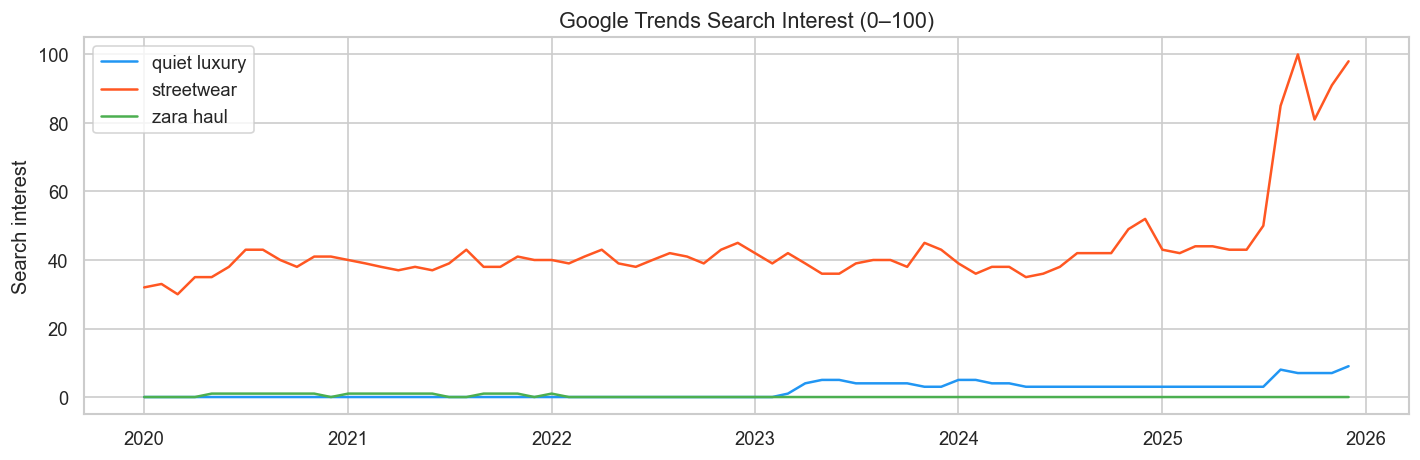

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = ['#2196F3', '#FF5722', '#4CAF50']
for col, color in zip(trends.columns, colors):
    ax.plot(trends.index, trends[col], label=col, linewidth=1.5, color=color)

ax.set_title('Google Trends Search Interest (0–100)', fontsize=13)
ax.set_ylabel('Search interest')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Trends vs Stock Returns

The core question of the project. To compare them, I need to align the data - prices are daily, trends are weekly. I resample prices to weekly and compute the correlation between each keyword's search interest and the next week's return for the corresponding stock.

The "next week" part matters - I'm checking whether a spike in search interest this week predicts a return next week, not just correlates contemporaneously.

In [7]:
weekly_prices  = prices.resample('W').last()
weekly_returns = np.log(weekly_prices / weekly_prices.shift(1)).dropna()

# align all trends and returns on the same weekly index
aligned = trends.reindex(weekly_returns.index, method='nearest')

pairs = {
    'quiet luxury' : 'LVMH',
    'streetwear' : 'H&M',
    'zara haul' : 'Inditex',
}

print('Correlation: search interest (week t) vs stock return (week t+1)\n')
for keyword, stock in pairs.items():
    if keyword in aligned.columns and stock in weekly_returns.columns:
        x = aligned[keyword].shift(1)         
        y = weekly_returns[stock]              
        valid = pd.concat([x, y], axis=1).dropna()
        corr  = valid.corr().iloc[0, 1]
        print(f'  "{keyword}" → {stock}: r = {corr:.4f}')

Correlation: search interest (week t) vs stock return (week t+1)

  "quiet luxury" → LVMH: r = -0.0085
  "streetwear" → H&M: r = 0.0718
  "zara haul" → Inditex: r = 0.0210


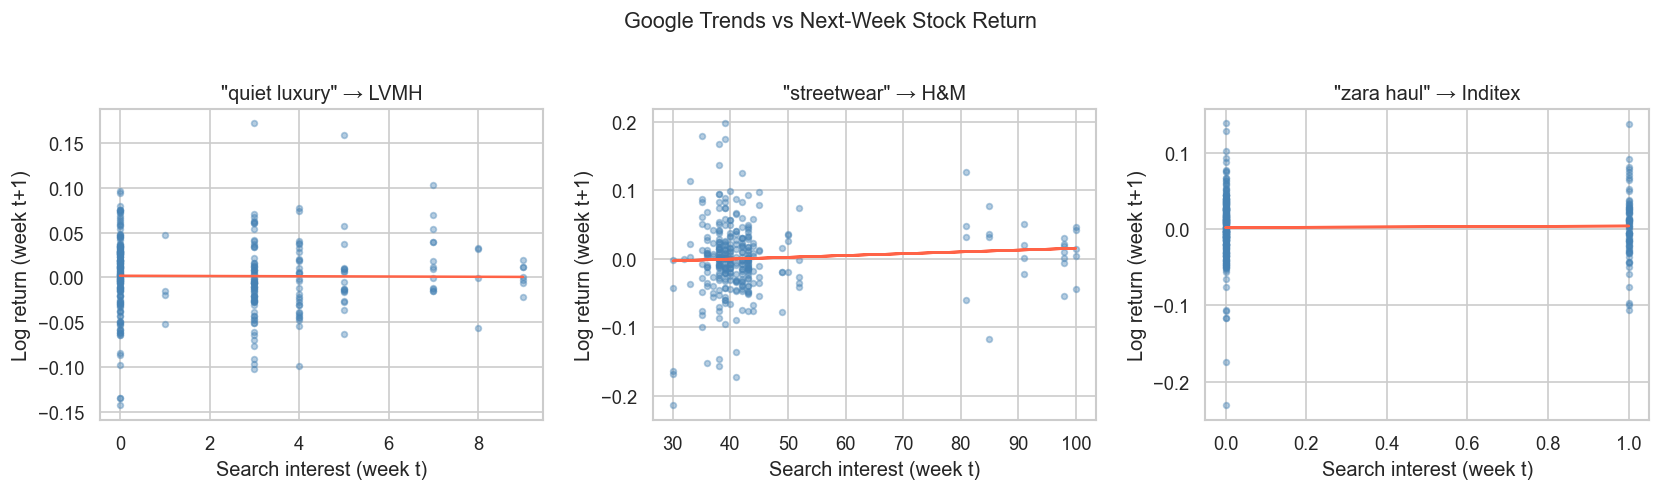

In [8]:
# scatter plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (keyword, stock) in zip(axes, pairs.items()):
    if keyword not in aligned.columns or stock not in weekly_returns.columns:
        ax.set_visible(False)
        continue

    x     = aligned[keyword].shift(1)
    y     = weekly_returns[stock]
    valid = pd.concat([x, y], axis=1).dropna()
    valid.columns = ['trend', 'return']

    ax.scatter(valid['trend'], valid['return'], alpha=0.4, s=12, color='steelblue')
    m, b = np.polyfit(valid['trend'], valid['return'], 1)
    ax.plot(valid['trend'], m * valid['trend'] + b, color='tomato', linewidth=1.5)

    ax.set_title(f'"{keyword}" → {stock}')
    ax.set_xlabel('Search interest (week t)')
    ax.set_ylabel('Log return (week t+1)')

fig.suptitle('Google Trends vs Next-Week Stock Return', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Macro Context

A quick look at disposable income and consumer spending over the same period — just to have the macro backdrop visible when interpreting the stock performance later.

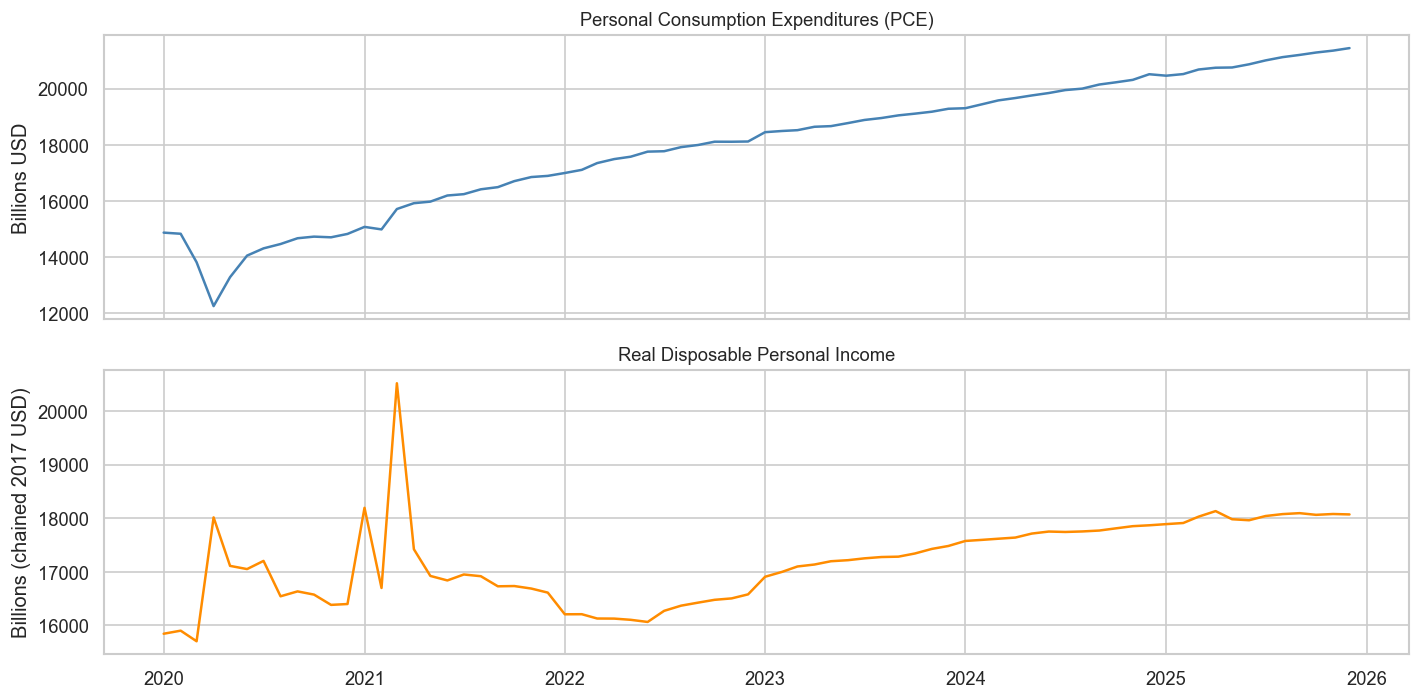

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(macro.index, macro['pce'], color='steelblue', linewidth=1.5)
axes[0].set_title('Personal Consumption Expenditures (PCE)', fontsize=11)
axes[0].set_ylabel('Billions USD')

axes[1].plot(macro.index, macro['disposable_income'], color='darkorange', linewidth=1.5)
axes[1].set_title('Real Disposable Personal Income', fontsize=11)
axes[1].set_ylabel('Billions (chained 2017 USD)')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

To see whether macro changes actually correlate with returns, I need to match frequencies - monthly PCE growth vs monthly stock returns — and then check it pair by pair.

In [ ]:
# monthly returns to match macro frequency
monthly_prices  = prices.resample('ME').last()
monthly_prices.index  = monthly_prices.index.to_period('M').to_timestamp()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

# month-over-month change in macro series
pce_growth    = macro['pce'].pct_change().dropna() * 100
income_growth = macro['disposable_income'].pct_change().dropna() * 100

# align
common_idx     = monthly_returns.index.intersection(pce_growth.index)
ret_aligned    = monthly_returns.loc[common_idx]
pce_aligned    = pce_growth.loc[common_idx]
income_aligned = income_growth.loc[common_idx]

corr_pce    = ret_aligned.corrwith(pce_aligned).rename('Correlation with PCE growth')
corr_income = ret_aligned.corrwith(income_aligned).rename('Correlation with income growth')

macro_corr = pd.concat([corr_pce, corr_income], axis=1).round(3)
print(f'Common months: {len(common_idx)}')
print('Correlation: monthly macro changes vs monthly stock returns\n')
print(macro_corr)

Common months: 71
Correlation: monthly macro changes vs monthly stock returns

          Corr with PCE growth  Corr with Income growth
H&M                      0.088                   -0.022
Inditex                  0.097                   -0.109
LVMH                     0.108                   -0.024
Tapestry                 0.065                   -0.046


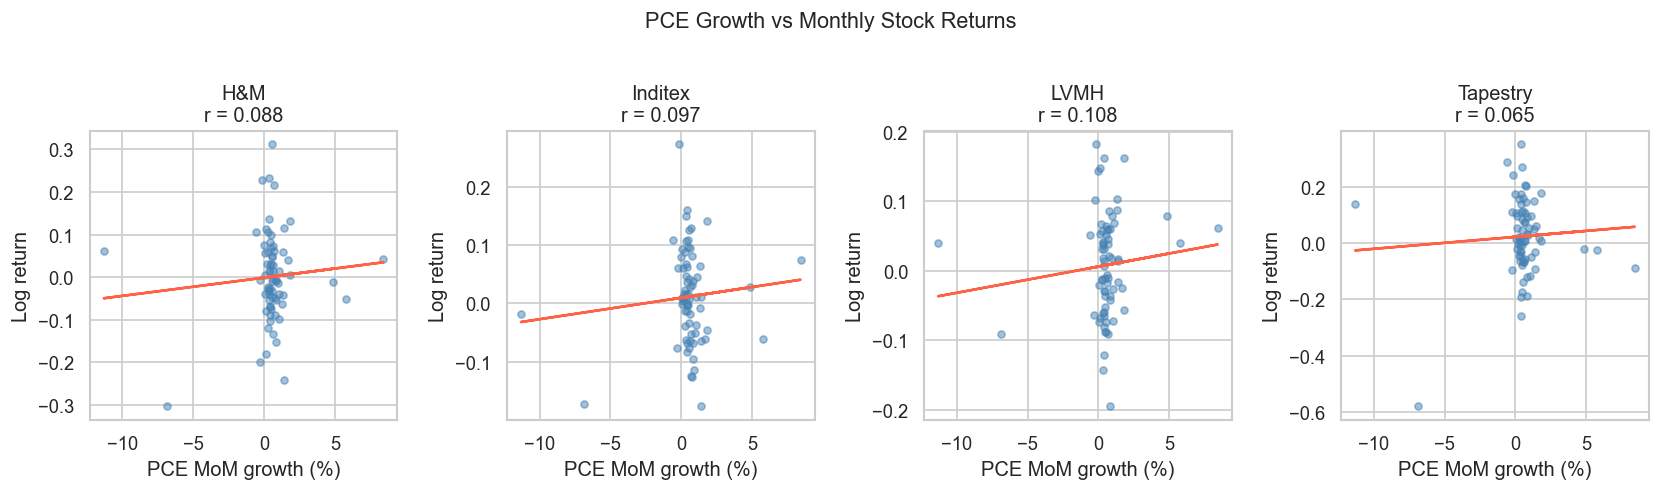

In [11]:
fig, axes = plt.subplots(1, len(ret_aligned.columns), figsize=(14, 4), sharey=False)

for ax, col in zip(axes, ret_aligned.columns):
    x = pce_aligned
    y = ret_aligned[col]
    valid = pd.concat([x, y], axis=1).dropna()
    valid.columns = ['pce', 'ret']

    if len(valid) < 3:
        ax.set_title(f'{col}\n(insufficient data)')
        ax.set_xlabel('PCE MoM growth (%)')
        continue

    ax.scatter(valid['pce'], valid['ret'], alpha=0.5, s=18, color='steelblue')
    m, b = np.polyfit(valid['pce'].values, valid['ret'].values, 1)
    ax.plot(valid['pce'], m * valid['pce'] + b, color='tomato', linewidth=1.5)
    r = valid.corr().iloc[0, 1]
    ax.set_title(f'{col}\nr = {r:.3f}')
    ax.set_xlabel('PCE MoM growth (%)')
    ax.set_ylabel('Log return')

fig.suptitle('PCE Growth vs Monthly Stock Returns', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

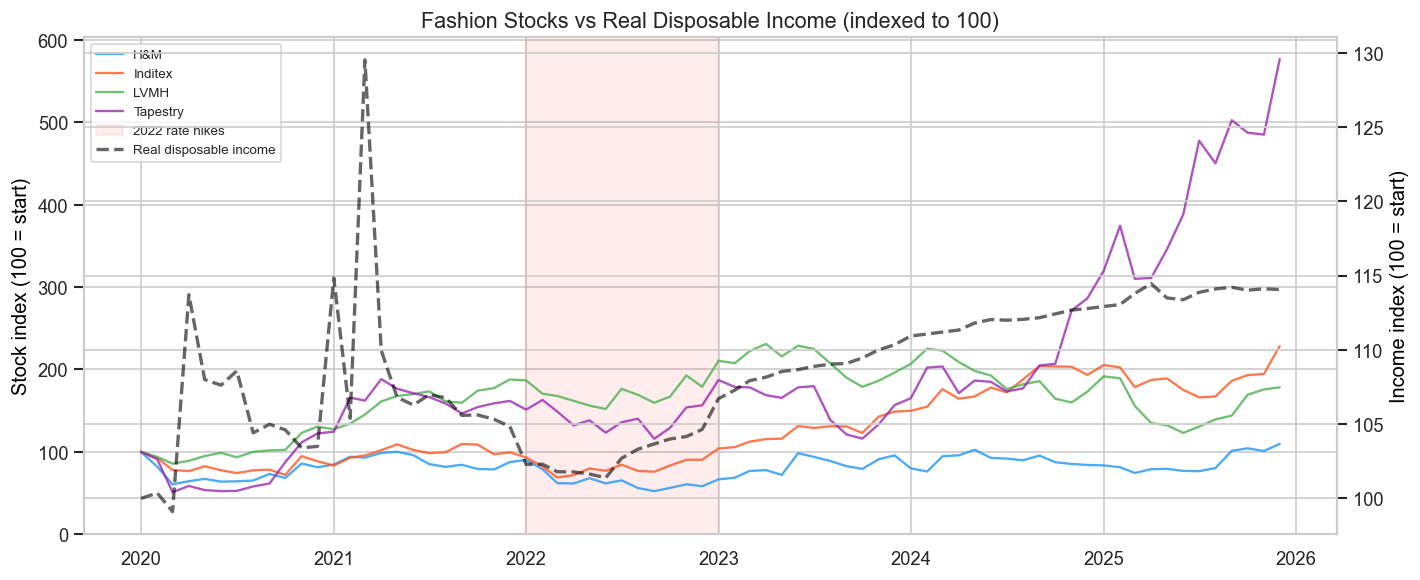

In [ ]:
# normalized cumulative returns + disposable income indexed to 100
fig, ax1 = plt.subplots(figsize=(12, 5))

norm = monthly_prices / monthly_prices.iloc[0] * 100
colors_stocks = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
for col, color in zip(norm.columns, colors_stocks):
    ax1.plot(norm.index, norm[col], linewidth=1.4, color=color, label=col, alpha=0.8)

ax1.set_ylabel('Stock index (100 = start)', color='black')
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
income_idx = macro['disposable_income'] / macro['disposable_income'].iloc[0] * 100
ax2.plot(income_idx.index, income_idx, linewidth=2, color='black',
         linestyle='--', label='Real disposable income', alpha=0.6)
ax2.set_ylabel('Income index (100 = start)', color='black')

ax1.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
            alpha=0.07, color='red', label='2022 rate hikes')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

ax1.set_title('Fashion Stocks vs Real Disposable Income (indexed to 100)', fontsize=13)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### Single-regime assumption
A single correlation matrix computed over 2020–2025 mixes at least three structurally different periods: the COVID crash and recovery (2020), the stimulus-driven income spike (2020–2021), and the rate-hike drawdown (2022). A rolling correlation would show how unstable these relationships actually are over time.